# 01 – Exploratory Data Analysis
**Project:** SmartBank Customer Churn — Lloyds Banking Group Data Science Programme  
**Author:**  Graduate Data Scientist  
**Objective:** Understand the five raw data sources, identify key patterns, and form hypotheses for feature engineering.


In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.data.load_data import load_raw_data
from src.utils.config import RAW_DATA_PATH

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (10, 5)})
print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load all five sheets

In [2]:
all_sheets = pd.read_excel(RAW_DATA_PATH, sheet_name=None)
for name, df in all_sheets.items():
    print(f'{name:30s} → {df.shape[0]:,} rows × {df.shape[1]} cols')

Customer_Demographics          → 1,000 rows × 5 cols
Transaction_History            → 5,054 rows × 5 cols
Customer_Service               → 1,002 rows × 5 cols
Online_Activity                → 1,000 rows × 4 cols
Churn_Status                   → 1,000 rows × 2 cols


In [3]:
# Load the merged frame (1 row per customer)
df = load_raw_data()
print(f'Merged shape: {df.shape}')
df.head()

2026-04-29 12:26:53 | INFO     | src.data.load_data | Loading sheet 'Customer_Demographics' …
2026-04-29 12:26:53 | INFO     | src.data.load_data |   → 1000 rows, 5 cols
2026-04-29 12:26:53 | INFO     | src.data.load_data | Loading sheet 'Transaction_History' …
2026-04-29 12:26:53 | INFO     | src.data.load_data |   → 5054 rows, 5 cols
2026-04-29 12:26:53 | INFO     | src.data.load_data | Loading sheet 'Customer_Service' …
2026-04-29 12:26:53 | INFO     | src.data.load_data |   → 1002 rows, 5 cols
2026-04-29 12:26:53 | INFO     | src.data.load_data | Loading sheet 'Online_Activity' …
2026-04-29 12:26:54 | INFO     | src.data.load_data |   → 1000 rows, 4 cols
2026-04-29 12:26:54 | INFO     | src.data.load_data | Loading sheet 'Churn_Status' …
2026-04-29 12:26:54 | INFO     | src.data.load_data |   → 1000 rows, 2 cols
2026-04-29 12:26:54 | INFO     | src.data.load_data | Merging all sources on CustomerID …
2026-04-29 12:26:54 | INFO     | src.data.load_data | Merge complete → 1000 rows, 

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,TotalSpent,AvgTransactionValue,NumTransactions,TopProductCategory,NumServiceInteractions,UnresolvedInteractions,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,1,62,M,Single,Low,416.50,416.50000,1,Electronics,1,0,2023-10-21,34,Mobile App,0
1,2,65,M,Married,Low,1547.42,221.06000,7,Electronics,1,0,2023-12-05,5,Website,1
2,3,18,M,Single,Low,1702.98,283.83000,6,Groceries,1,0,2023-11-15,3,Website,0
3,4,21,M,Widowed,Low,917.29,183.45800,5,Electronics,2,1,2023-08-25,2,Website,0
4,5,21,M,Divorced,Medium,2001.49,250.18625,8,Groceries,0,0,2023-10-27,41,Website,0


## 2. Data Quality Checks

In [4]:
# Missing values
missing = df.isnull().sum().rename('Missing').to_frame()
missing['%'] = (missing['Missing'] / len(df) * 100).round(2)
missing[missing['Missing'] > 0]

,Missing,%


In [5]:
# Dtypes
df.dtypes

CustomerID                         int64
Age                                int64
Gender                            object
MaritalStatus                     object
IncomeLevel                       object
TotalSpent                       float64
AvgTransactionValue              float64
NumTransactions                    int64
TopProductCategory                object
NumServiceInteractions             int64
UnresolvedInteractions             int64
LastLoginDate             datetime64[ns]
LoginFrequency                     int64
ServiceUsage                      object
ChurnStatus                        int64
dtype: object

In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
CustomerID,1000.0,NaN,NaN,NaN,500.5,1.0,250.75,500.5,750.25,1000.0,288.819436
Age,1000.0,NaN,NaN,NaN,43.267,18.0,30.0,43.0,56.0,69.0,15.242311
Gender,1000,2,F,513,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MaritalStatus,1000,4,Widowed,276,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IncomeLevel,1000,3,High,349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TotalSpent,1000.0,NaN,NaN,NaN,1267.07495,9.8,626.685,1232.88,1791.9025,3386.04,738.590013
AvgTransactionValue,1000.0,NaN,NaN,NaN,248.806511,9.8,203.734167,250.121458,295.023854,496.99,79.372766
NumTransactions,1000.0,NaN,NaN,NaN,5.054,1.0,3.0,5.0,7.0,9.0,2.603433
TopProductCategory,1000,5,Books,208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NumServiceInteractions,1000.0,NaN,NaN,NaN,1.002,0.0,0.0,1.0,2.0,2.0,0.816494


In [7]:
df.isnull().sum()

CustomerID                0
Age                       0
Gender                    0
MaritalStatus             0
IncomeLevel               0
TotalSpent                0
AvgTransactionValue       0
NumTransactions           0
TopProductCategory        0
NumServiceInteractions    0
UnresolvedInteractions    0
LastLoginDate             0
LoginFrequency            0
ServiceUsage              0
ChurnStatus               0
dtype: int64

## 3. Target Variable — Churn Distribution

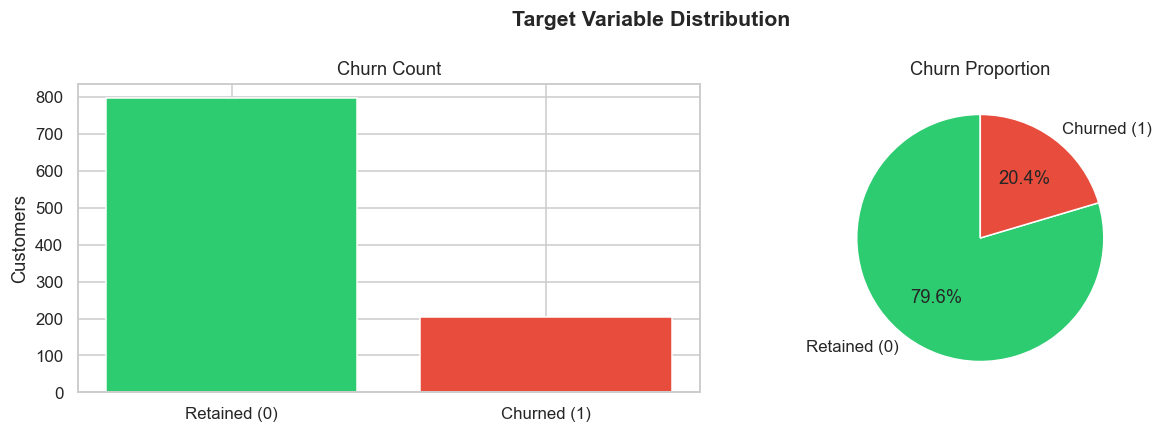

Churn rate: 20.4%


In [8]:
churn_counts = df['ChurnStatus'].value_counts()
labels = ['Retained (0)', 'Churned (1)']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(labels, churn_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn Count')
axes[0].set_ylabel('Customers')

axes[1].pie(churn_counts.values, labels=labels,
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Churn Proportion')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Churn rate: {df["ChurnStatus"].mean()*100:.1f}%')

## 4. Numerical Features — Distributions

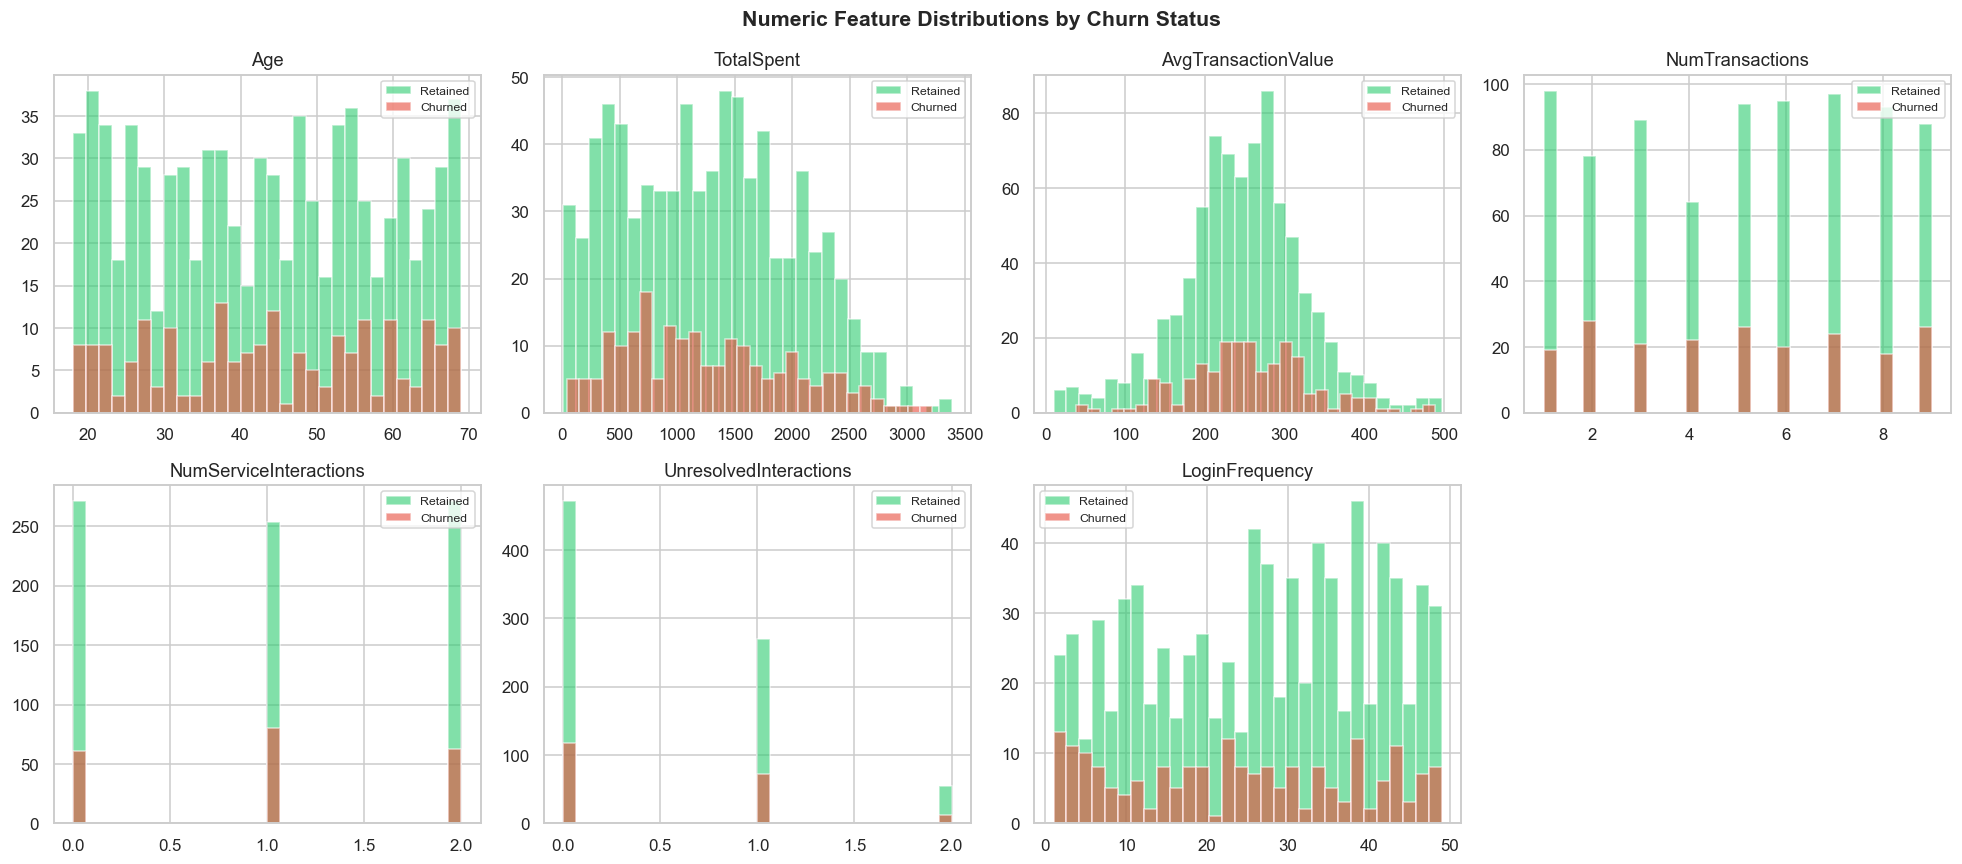

In [9]:
num_cols = ['Age', 'TotalSpent', 'AvgTransactionValue',
            'NumTransactions', 'NumServiceInteractions',
            'UnresolvedInteractions', 'LoginFrequency']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for val, colour, label in [(0, '#2ecc71', 'Retained'), (1, '#e74c3c', 'Churned')]:
        axes[i].hist(df[df['ChurnStatus'] == val][col].dropna(),
                     bins=30, alpha=0.6, color=colour, label=label)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

axes[-1].axis('off')
plt.suptitle('Numeric Feature Distributions by Churn Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Categorical Features vs Churn

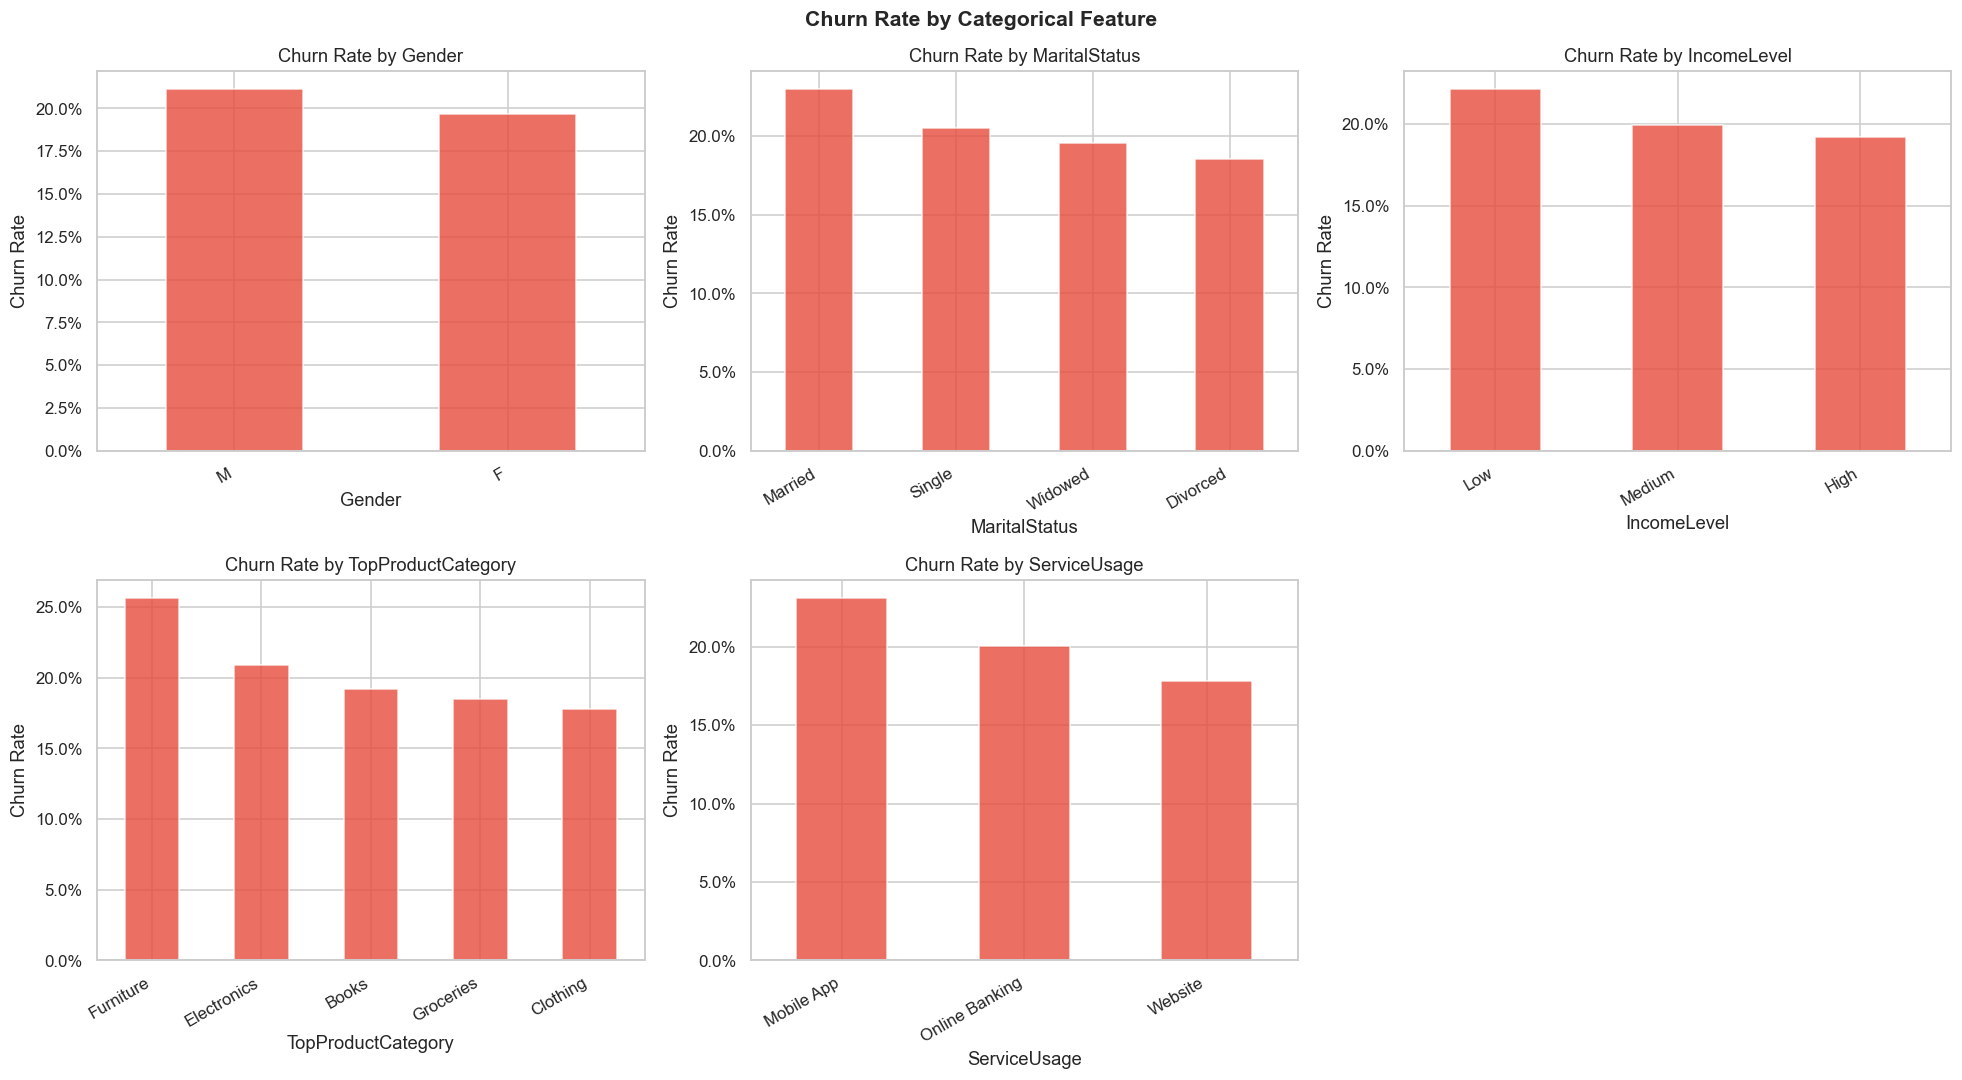

In [10]:
cat_cols = ['Gender', 'MaritalStatus', 'IncomeLevel',
            'TopProductCategory', 'ServiceUsage']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['ChurnStatus'].mean().sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=axes[i], color='#e74c3c', alpha=0.8, edgecolor='white')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')
    axes[i].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

axes[-1].axis('off')
plt.suptitle('Churn Rate by Categorical Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Correlation Heatmap

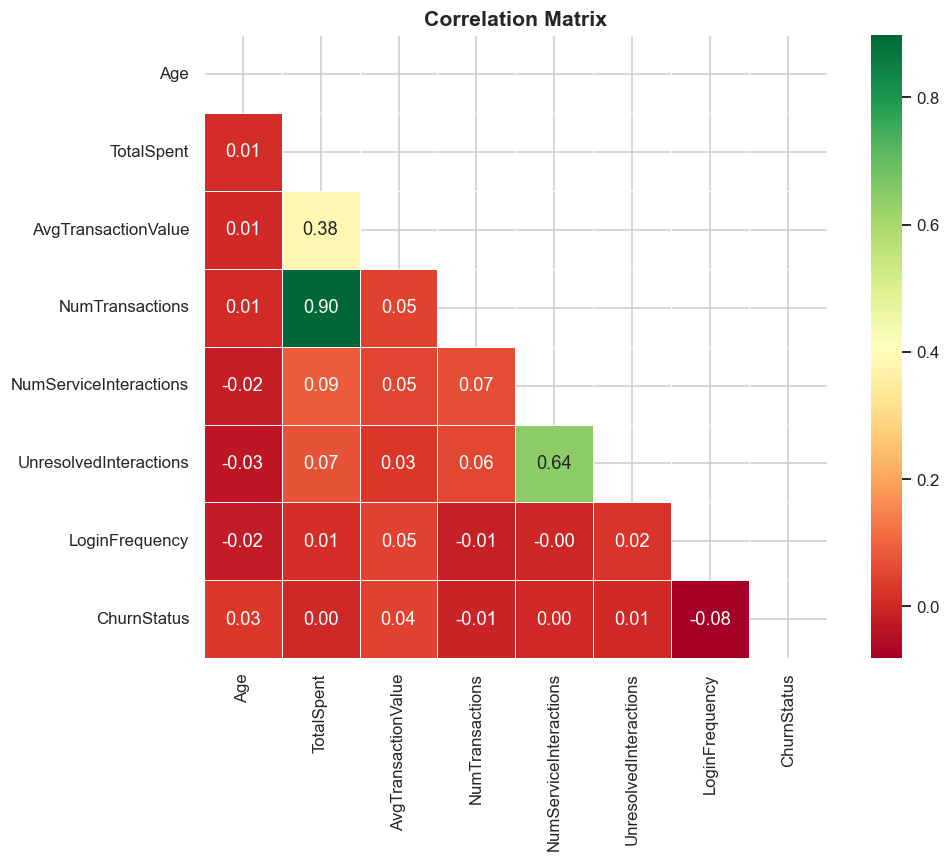

In [11]:
corr = df[num_cols + ['ChurnStatus']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, square=True)
ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Box Plots — Numeric vs Churn

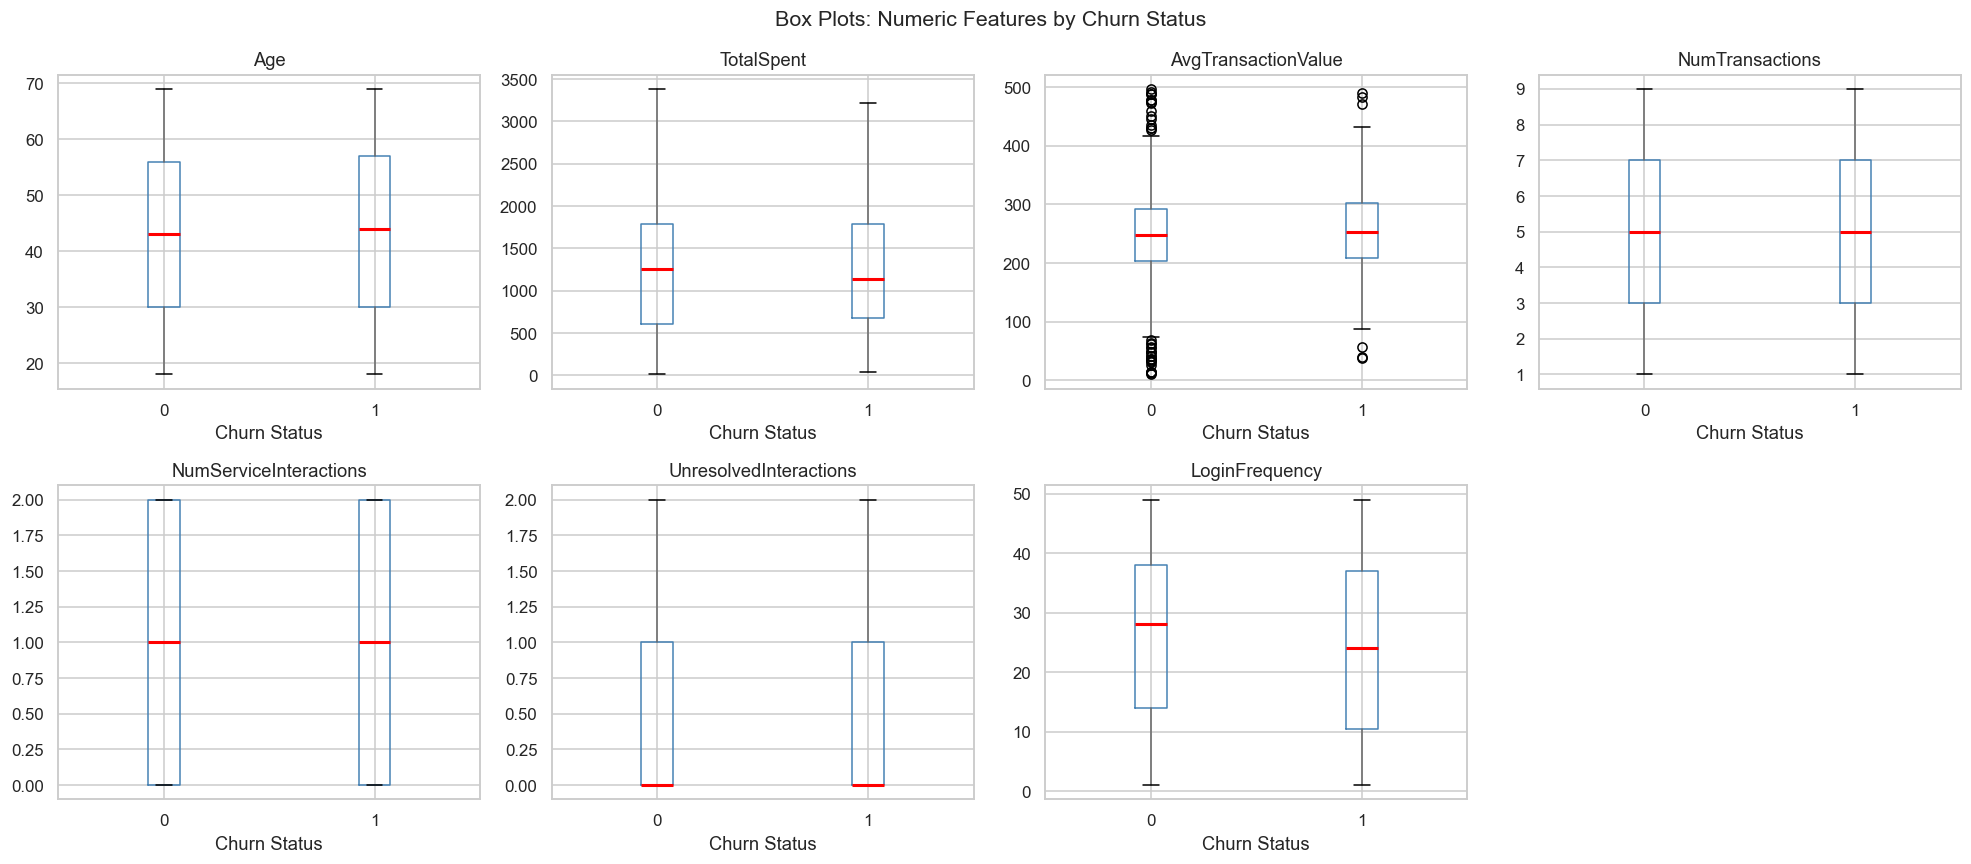

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='ChurnStatus', ax=axes[i],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col)
    axes[i].set_xlabel('Churn Status')

axes[-1].axis('off')
plt.suptitle('Box Plots: Numeric Features by Churn Status', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Transaction Trends — Monthly Spend

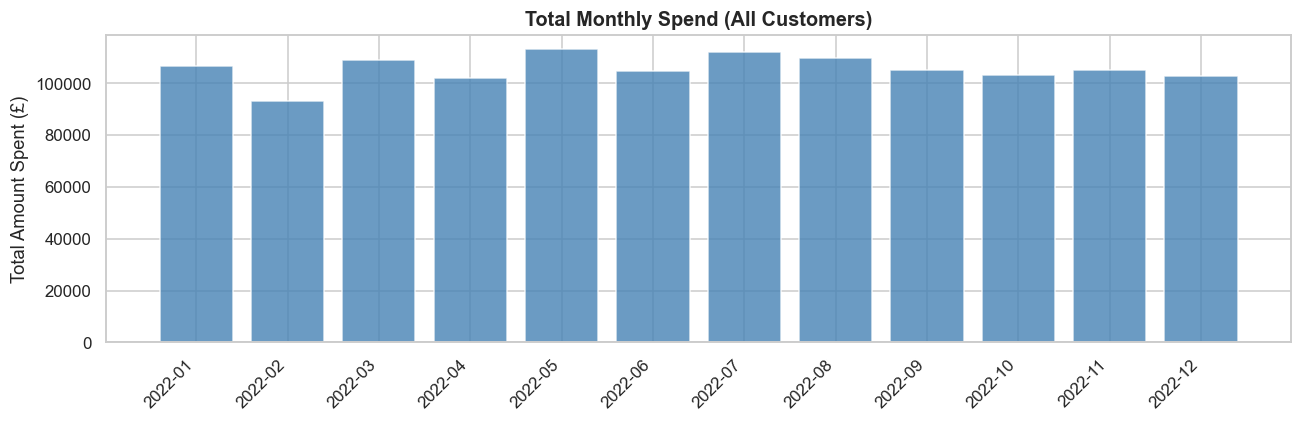

In [13]:
txn = all_sheets['Transaction_History'].copy()
txn['Month'] = pd.to_datetime(txn['TransactionDate']).dt.to_period('M')
monthly = txn.groupby('Month')['AmountSpent'].sum().reset_index()
monthly['Month'] = monthly['Month'].astype(str)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(monthly['Month'], monthly['AmountSpent'], color='steelblue', alpha=0.8)
ax.set_title('Total Monthly Spend (All Customers)', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Amount Spent (£)')
ax.set_xticklabels(monthly['Month'], rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 9. Key Findings & Hypotheses

| Finding | Business Implication |
|---|---|
| **Churn rate ≈ 20.4 %** — moderately imbalanced | Use `class_weight='balanced'` or SMOTE during training |
| **Unresolved service interactions** strongly associated with churn | Reduce resolution time; prioritise at-risk customers |
| **Low login frequency** → higher churn | Re-engagement campaigns for low-activity customers |
| **Income level & marital status** show churn rate differences | Tailor retention offers by segment |
| **Low total spend** correlates with churn | Early lifecycle intervention for low-value accounts |

These findings will drive feature engineering decisions in notebook `02_feature_engineering.ipynb`.
